# Noisy Intent Detection — Character-Level & Token-Free Models

**Setup:** Train Clean → Test Noisy  |  Dataset: CLINC (oos-eval)

| Model | Type |
|---|---|
| CharBiLSTM | Character-level tokenizer |
| CANINE-s | Token-free encoder |

**Noise types:** Spelling 20% · Casing (ALL CAPS) · Keyboard 15% · Synonyms 20% · Abbreviations (Webopedia) · TTS transcription

**Metrics:** Accuracy (in-scope) · OOS Recall

In [21]:
import json, os, re, random, pathlib
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import nltk
nltk.download("wordnet",                    quiet=True)
nltk.download("averaged_perceptron_tagger", quiet=True)
nltk.download("omw-1.4",                   quiet=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

SAVE_DIR = pathlib.Path("./charLVL_output/")  

print(f"torch : {torch.__version__}")
print(f"device: {device}")
if device.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

torch : 2.9.0+cu128
device: cuda
GPU   : NVIDIA GeForce RTX 4080 SUPER


In [22]:
CLINC_PATH = "./dataset/data_full.json"
with open(CLINC_PATH) as f:
    data = json.load(f)

train_texts  = [x[0] for x in data["train"]]
train_labels = [x[1] for x in data["train"]]
test_texts   = [x[0] for x in data["test"]]
test_labels  = [x[1] for x in data["test"]]
val_texts    = [x[0] for x in data["val"]]
val_labels   = [x[1] for x in data["val"]]

oos_train_texts = [x[0] for x in data["oos_train"]]
oos_val_texts   = [x[0] for x in data["oos_val"]]
oos_test_texts  = [x[0] for x in data["oos_test"]]

print(f"In-scope → train: {len(train_texts)}, test: {len(test_texts)}, val: {len(val_texts)}")
print(f"OOS      → train: {len(oos_train_texts)}, test: {len(oos_test_texts)}, val: {len(oos_val_texts)}")
print(f"Sample: {test_texts[0]!r} → {test_labels[0]}")

In-scope → train: 15000, test: 4500, val: 3000
OOS      → train: 100, test: 1000, val: 100
Sample: 'how would you say fly in italian' → translate


In [23]:
in_scope = sorted(set(train_labels))
OOS_LABEL = "oos"
all_intent_labels = in_scope + [OOS_LABEL]
label2id = {l: i for i, l in enumerate(all_intent_labels)}
id2label  = {i: l for l, i in label2id.items()}
NUM_LABELS = len(all_intent_labels)
OOS_ID     = label2id[OOS_LABEL]

print(f"Total classes: {NUM_LABELS}  (OOS id = {OOS_ID})")

all_train_texts  = train_texts  + oos_train_texts
all_train_labels = [label2id[l] for l in train_labels] + [OOS_ID]*len(oos_train_texts)
all_val_texts    = val_texts    + oos_val_texts
all_val_labels   = [label2id[l] for l in val_labels]   + [OOS_ID]*len(oos_val_texts)

test_ids     = [label2id[l] for l in test_labels]
oos_test_ids = [OOS_ID] * len(oos_test_texts)

Total classes: 151  (OOS id = 150)


In [24]:
import nlpaug.augmenter.char as nac
import nlpaug.augmenter.word as naw

def add_casing_noise(texts):
    """ALL UPPERCASE."""
    return [t.upper() for t in texts]

def add_keyboard_noise(texts, aug_char_p=0.15):
    """Keyboard typos at 15 % character rate."""
    aug = nac.KeyboardAug(aug_char_p=aug_char_p)
    out = []
    for t in texts:
        try:    out.append(aug.augment(t)[0])
        except: out.append(t)
    return out

def add_spelling_noise(texts, aug_p=0.2):
    """Spelling errors at 20 % word rate."""
    aug = naw.SpellingAug(aug_p=aug_p)
    out = []
    for t in texts:
        try:    out.append(aug.augment(t)[0])
        except: out.append(t)
    return out

def add_synonym_noise(texts, aug_p=0.2):
    """WordNet synonym substitution at 20 % word rate."""
    aug = naw.SynonymAug(aug_p=aug_p)
    out = []
    for t in texts:
        try:    out.append(aug.augment(t)[0])
        except: out.append(t)
    return out

In [25]:
ABBREV_MAP = {
    "you": "u", "your": "ur", "you're": "ur", "are": "r", "be": "b",
    "see": "c", "okay": "ok", "please": "pls", "thanks": "thx",
    "thank": "thx", "and": "&", "at": "@", "with": "w/", "without": "w/o",
    "tomorrow": "tmrw", "tonight": "2nite", "today": "2day",
    "before": "b4", "later": "l8r", "wait": "w8", "great": "gr8",
    "late": "l8", "good": "gd", "love": "luv", "hate": "h8",
    "information": "info", "application": "app", "number": "#",
    "message": "msg", "messages": "msgs", "account": "acct",
    "appointment": "appt", "maximum": "max", "minimum": "min",
    "approximately": "approx", "department": "dept",
    "management": "mgmt", "assistant": "asst",
    "about": "abt", "because": "bc", "probably": "prob",
    "really": "rly", "people": "ppl", "something": "sth",
    "though": "tho", "through": "thru", "enough": "enuff",
    "what": "wut", "where": "whr", "when": "wen",
    "would": "wld", "could": "cld", "should": "shld",
    "financial": "fin", "transaction": "txn", "balance": "bal",
    "transfer": "xfer", "currency": "curr", "international": "intl",
    "available": "avail", "payment": "pymnt", "schedule": "sched",
}

def add_abbreviation_noise(texts):
    """Replace common words with text abbreviations (Webopedia)."""
    return [" ".join(ABBREV_MAP.get(w.lower(), w) for w in t.split()) for t in texts]


HOMOPHONES = {
    "their": "there", "there": "their", "they're": "there",
    "your": "you're", "you're": "your",
    "its": "it's",   "it's": "its",
    "to": "too",     "two": "to",    "too": "to",
    "for": "four",   "four": "for",
    "by": "buy",     "buy": "by",
    "no": "know",    "know": "no",
    "new": "knew",   "knew": "new",
    "here": "hear",  "hear": "here",
    "our": "hour",   "hour": "our",
    "right": "write","write": "right",
    "whether": "weather", "weather": "whether",
    "which": "witch","witch": "which",
    "wear": "where", "where": "wear",
    "meet": "meat",  "meat": "meet",
    "affect": "effect", "effect": "affect",
}

CONTRACTIONS_EXPAND = {
    "i'm": "i am",       "i've": "i have",   "i'll": "i will",
    "i'd": "i would",    "you're": "you are", "it's": "it is",
    "that's": "that is", "there's": "there is","what's": "what is",
    "how's": "how is",   "don't": "do not",  "doesn't": "does not",
    "didn't": "did not", "won't": "will not", "can't": "cannot",
    "couldn't": "could not", "shouldn't": "should not",
    "isn't": "is not",   "aren't": "are not", "wasn't": "was not",
    "haven't": "have not","hasn't": "has not",
}

ASR_FILLERS = ["uh", "um", "like"]

def add_tts_noise(texts):
    """Simulate TTS→ASR transcription: homophone swaps, contraction expansion, fillers."""
    rng = random.Random(SEED)
    out = []
    for t in texts:
        words, new = t.split(), []
        for w in words:
            wl = w.lower()
            if wl in CONTRACTIONS_EXPAND and rng.random() < 0.5:
                new.extend(CONTRACTIONS_EXPAND[wl].split())
            elif wl in HOMOPHONES and rng.random() < 0.25:
                new.append(HOMOPHONES[wl])
            else:
                new.append(w)
        if rng.random() < 0.08 and len(new) > 2:
            new.insert(rng.randint(1, len(new)-1), rng.choice(ASR_FILLERS))
        out.append(" ".join(new))
    return out

In [26]:
print("Generating noise variants for in-scope test set…")
print("  casing…      ", end="", flush=True)
noisy_casing   = add_casing_noise(test_texts);      print("done")
print("  keyboard…    ", end="", flush=True)
noisy_keyboard = add_keyboard_noise(test_texts);    print("done")
print("  spelling…    ", end="", flush=True)
noisy_spelling = add_spelling_noise(test_texts);    print("done")
print("  synonyms…    ", end="", flush=True)
noisy_synonyms = add_synonym_noise(test_texts);     print("done")
print("  abbreviations…", end="", flush=True)
noisy_abbrev   = add_abbreviation_noise(test_texts);print("done")
print("  tts…         ", end="", flush=True)
noisy_tts      = add_tts_noise(test_texts);         print("done")

noise_variants = {
    "original":      test_texts,
    "casing":        noisy_casing,
    "keyboard":      noisy_keyboard,
    "spelling":      noisy_spelling,
    "synonyms":      noisy_synonyms,
    "abbreviations": noisy_abbrev,
    "tts":           noisy_tts,
}

print("\nGenerating noise variants for OOS test set…")
noisy_oos_variants = {
    "original":      oos_test_texts,
    "casing":        add_casing_noise(oos_test_texts),
    "keyboard":      add_keyboard_noise(oos_test_texts),
    "spelling":      add_spelling_noise(oos_test_texts),
    "synonyms":      add_synonym_noise(oos_test_texts),
    "abbreviations": add_abbreviation_noise(oos_test_texts),
    "tts":           add_tts_noise(oos_test_texts),
}

print("\n── Sample transformations (first test example) ──")
print(f"original:      {test_texts[0]!r}")
for name in list(noise_variants.keys())[1:]:
    print(f"{name:<15}{noise_variants[name][0]!r}")

Generating noise variants for in-scope test set…
  casing…      done
  keyboard…    done
  spelling…    done
  synonyms…    

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package aver

done
  abbreviations…done
  tts…         

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package aver

done

Generating noise variants for OOS test set…


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package aver


── Sample transformations (first test example) ──
original:      'how would you say fly in italian'
casing         'HOW WOULD YOU SAY FLY IN ITALIAN'
keyboard       'how woHld you say fly in i5aliaj'
spelling       'Hou would oyou say fly in italian'
synonyms       'how would you say fly in italian'
abbreviations  'how wld u say fly in italian'
tts            'how would you say fly in italian'


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\vladi\AppData\Roaming\nltk_data...
[nltk_data]   Package aver

In [27]:
class CharVocab:
    PAD, UNK = 0, 1
    def __init__(self):
        self.char2idx = {"<PAD>": 0, "<UNK>": 1}
    def build(self, texts):
        for t in texts:
            for ch in t:
                if ch not in self.char2idx:
                    self.char2idx[ch] = len(self.char2idx)
        print(f"Character vocabulary size: {len(self)}")
    def encode(self, text, max_len=256):
        ids = [self.char2idx.get(ch, 1) for ch in text[:max_len]]
        return ids + [0] * (max_len - len(ids))
    def __len__(self):
        return len(self.char2idx)

MAX_CHAR_LEN = 256
vocab = CharVocab()
vocab.build(all_train_texts)

enc = vocab.encode("hello WORLD! 123", MAX_CHAR_LEN)
print(f"Sample encoding (first 20 ids): {enc[:20]}")

Character vocabulary size: 58
Sample encoding (first 20 ids): [3, 7, 16, 16, 13, 6, 1, 1, 1, 1, 1, 51, 6, 35, 33, 43, 0, 0, 0, 0]


In [28]:
class CharDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=256):
        self.x = torch.tensor([vocab.encode(t, max_len) for t in texts], dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.long)
    def __len__(self):         return len(self.y)
    def __getitem__(self, i):  return self.x[i], self.y[i]


class CharBiLSTM(nn.Module):
    """Bidirectional LSTM over character embeddings."""
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=256,
                 num_layers=2, num_classes=151, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm  = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers,
                             bidirectional=True, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        emb = self.drop(self.embed(x))
        _, (h, _) = self.lstm(emb)
        h = torch.cat([h[-2], h[-1]], dim=-1)   # fwd + bwd final states
        return self.fc(self.drop(h))


char_model = CharBiLSTM(
    vocab_size=len(vocab), embed_dim=64, hidden_dim=256,
    num_layers=2, num_classes=NUM_LABELS, dropout=0.3
).to(device)
print(f"CharBiLSTM parameters: {sum(p.numel() for p in char_model.parameters()):,}")

CharBiLSTM parameters: 2,317,591


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train(); total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

@torch.no_grad()
def val_acc(model, loader):
    model.eval(); preds, truths = [], []
    for x, y in loader:
        preds.extend(torch.argmax(model(x.to(device)), 1).cpu())
        truths.extend(y)
    return accuracy_score(truths, preds)


# num_workers=0: required on Windows — Jupyter can't spawn DataLoader workers
NW = 0
PM = device.type == "cuda"   # pin_memory only helps with CUDA

train_ds = CharDataset(all_train_texts, all_train_labels, vocab, MAX_CHAR_LEN)
val_ds   = CharDataset(all_val_texts,   all_val_labels,   vocab, MAX_CHAR_LEN)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=NW, pin_memory=PM)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=NW, pin_memory=PM)

EPOCHS    = 15
optimizer = torch.optim.Adam(char_model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)

char_history = {"loss": [], "val_acc": []}
best_val, best_state = 0, None

for ep in range(1, EPOCHS + 1):
    loss = train_epoch(char_model, train_loader, optimizer, criterion)
    acc  = val_acc(char_model, val_loader)
    scheduler.step(loss)
    char_history["loss"].append(loss)
    char_history["val_acc"].append(acc)
    if acc > best_val:
        best_val   = acc
        best_state = {k: v.clone() for k, v in char_model.state_dict().items()}
    print(f"Ep {ep:2d}/{EPOCHS}  loss={loss:.4f}  val_acc={acc*100:.2f}%")

char_model.load_state_dict(best_state)
print(f"Best val accuracy: {best_val*100:.2f}%")

Ep  1/15  loss=4.7606  val_acc=6.61%
Ep  2/15  loss=3.9942  val_acc=20.52%
Ep  3/15  loss=3.1166  val_acc=34.39%
Ep  4/15  loss=2.3742  val_acc=47.55%
Ep  5/15  loss=1.7926  val_acc=56.84%
Ep  6/15  loss=1.3752  val_acc=63.42%
Ep  7/15  loss=1.0732  val_acc=67.74%
Ep  8/15  loss=0.8604  val_acc=70.39%
Ep  9/15  loss=0.6961  val_acc=74.52%
Ep 10/15  loss=0.5681  val_acc=75.23%
Ep 11/15  loss=0.4724  val_acc=77.13%
Ep 12/15  loss=0.3929  val_acc=78.61%
Ep 13/15  loss=0.3404  val_acc=79.26%
Ep 14/15  loss=0.2849  val_acc=80.58%
Ep 15/15  loss=0.2339  val_acc=80.06%
Best val accuracy: 80.58%


In [30]:
@torch.no_grad()
def evaluate_char(texts, label_ids):
    ds     = CharDataset(texts, label_ids, vocab, MAX_CHAR_LEN)
    loader = DataLoader(ds, batch_size=256, shuffle=False, num_workers=0)
    char_model.eval(); preds, truths = [], []
    for x, y in loader:
        preds.extend(torch.argmax(char_model(x.to(device)), 1).cpu().numpy())
        truths.extend(y.numpy())
    return np.array(preds), np.array(truths)

def oos_recall(preds, truths):
    mask = truths == OOS_ID
    return float((preds[mask] == OOS_ID).mean()) if mask.any() else float("nan")

char_results = {}
print(f"CharBiLSTM evaluation")
print("-" * 65)
for name in noise_variants:
    in_p, in_t   = evaluate_char(noise_variants[name],     test_ids)
    oos_p, oos_t = evaluate_char(noisy_oos_variants[name], oos_test_ids)
    acc  = accuracy_score(in_t, in_p)
    oosr = oos_recall(oos_p, oos_t)
    char_results[name] = {"accuracy": acc, "oos_recall": oosr}
    print(f"  {name:<16} acc={acc*100:5.2f}%  oos_recall={oosr*100:5.2f}%")

CharBiLSTM evaluation
-----------------------------------------------------------------
  original         acc=82.84%  oos_recall=13.30%
  casing           acc= 0.89%  oos_recall= 0.00%
  keyboard         acc=68.98%  oos_recall=12.80%
  spelling         acc=74.51%  oos_recall=12.00%
  synonyms         acc=82.84%  oos_recall=13.30%
  abbreviations    acc=76.60%  oos_recall=10.50%
  tts              acc=82.29%  oos_recall=12.00%


In [31]:
from transformers import CanineTokenizer, CanineForSequenceClassification
from transformers import TrainingArguments, Trainer

CANINE_CKPT = "google/canine-s"
CANINE_MAX  = 128

canine_tok   = CanineTokenizer.from_pretrained(CANINE_CKPT)
canine_model = CanineForSequenceClassification.from_pretrained(
    CANINE_CKPT, num_labels=NUM_LABELS, id2label=id2label, label2id=label2id
)

def canine_encode(texts):
    return canine_tok(
        texts, truncation=True, padding=True,
        max_length=CANINE_MAX, return_tensors="pt"
    )

class CanineDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc, self.labels = enc, labels
    def __len__(self):        return len(self.labels)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[i])
        return item

print("Encoding train/val for CANINE (this may take ~1-2 min)…")
canine_train_ds = CanineDataset(canine_encode(all_train_texts), all_train_labels)
canine_val_ds   = CanineDataset(canine_encode(all_val_texts),   all_val_labels)
print(f"Train size: {len(canine_train_ds)}, Val size: {len(canine_val_ds)}")

Some weights of CanineForSequenceClassification were not initialized from the model checkpoint at google/canine-s and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Encoding train/val for CANINE (this may take ~1-2 min)…
Train size: 15100, Val size: 3100


In [32]:
def hf_metrics(eval_pred):
    logits, labels = eval_pred
    return {"accuracy": accuracy_score(labels, np.argmax(logits, 1))}

canine_args = TrainingArguments(
    output_dir=str(SAVE_DIR / "canine-clinc"),
    num_train_epochs=15,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=(device.type == "cuda"),
    logging_steps=200,
    warmup_ratio=0.06,
    learning_rate=5e-5,
    weight_decay=0.01,
    report_to="none",
)

canine_trainer = Trainer(
    model=canine_model,
    args=canine_args,
    train_dataset=canine_train_ds,
    eval_dataset=canine_val_ds,
    compute_metrics=hf_metrics,
)
canine_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,4.633500,4.172629,0.067419
2,2.661700,2.366512,0.424194
3,1.372300,1.370082,0.650645
4,0.802900,1.037340,0.739032
5,0.524500,0.836430,0.815484
6,0.320200,0.720745,0.850000
7,0.226900,0.743578,0.863548
8,0.144400,0.735906,0.873226
9,0.085700,0.798411,0.872581
10,0.076600,0.797707,0.881290


TrainOutput(global_step=14160, training_loss=0.8161174769876367, metrics={'train_runtime': 674.6467, 'train_samples_per_second': 335.731, 'train_steps_per_second': 20.989, 'total_flos': 1.8616508468352e+16, 'train_loss': 0.8161174769876367, 'epoch': 15.0})

In [33]:
canine_model = canine_model.to(device)

@torch.no_grad()
def evaluate_canine(texts, label_ids):
    enc = canine_encode(texts)
    ds  = CanineDataset(enc, label_ids)
    ldr = DataLoader(ds, batch_size=32, shuffle=False)
    canine_model.eval(); preds, truths = [], []
    for batch in ldr:
        ids  = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        out  = canine_model(input_ids=ids, attention_mask=mask)
        preds.extend(torch.argmax(out.logits, 1).cpu().numpy())
        truths.extend(batch["labels"].numpy())
    return np.array(preds), np.array(truths)

canine_results = {}
print(f"CANINE evaluation\n{'─'*65}")
for name in noise_variants:
    in_p, in_t   = evaluate_canine(noise_variants[name],     test_ids)
    oos_p, oos_t = evaluate_canine(noisy_oos_variants[name], oos_test_ids)
    acc  = accuracy_score(in_t, in_p)
    oosr = oos_recall(oos_p, oos_t)
    canine_results[name] = {"accuracy": acc, "oos_recall": oosr}
    print(f"  {name:<16} acc={acc*100:5.2f}%  oos_recall={oosr*100:5.2f}%")

CANINE evaluation
─────────────────────────────────────────────────────────────────
  original         acc=90.44%  oos_recall=30.70%
  casing           acc=87.27%  oos_recall=30.80%
  keyboard         acc=67.82%  oos_recall=40.30%
  spelling         acc=85.80%  oos_recall=31.40%
  synonyms         acc=90.44%  oos_recall=30.70%
  abbreviations    acc=84.91%  oos_recall=28.80%
  tts              acc=89.82%  oos_recall=31.80%


In [34]:
NOISE_NAMES = list(noise_variants.keys())

print("\n" + "="*70)
print(f"{'Model':<14} {'Noise':<16} {'Accuracy':>10} {'OOS-Recall':>12}")
print("="*70)
for model_name, res in [("CharBiLSTM", char_results), ("CANINE-s", canine_results)]:
    for n in NOISE_NAMES:
        r = res[n]
        print(f"{model_name:<14} {n:<16} {r['accuracy']*100:>9.2f}%  {r['oos_recall']*100:>10.2f}%")
    print("-"*70)


Model          Noise              Accuracy   OOS-Recall
CharBiLSTM     original             82.84%       13.30%
CharBiLSTM     casing                0.89%        0.00%
CharBiLSTM     keyboard             68.98%       12.80%
CharBiLSTM     spelling             74.51%       12.00%
CharBiLSTM     synonyms             82.84%       13.30%
CharBiLSTM     abbreviations        76.60%       10.50%
CharBiLSTM     tts                  82.29%       12.00%
----------------------------------------------------------------------
CANINE-s       original             90.44%       30.70%
CANINE-s       casing               87.27%       30.80%
CANINE-s       keyboard             67.82%       40.30%
CANINE-s       spelling             85.80%       31.40%
CANINE-s       synonyms             90.44%       30.70%
CANINE-s       abbreviations        84.91%       28.80%
CANINE-s       tts                  89.82%       31.80%
----------------------------------------------------------------------


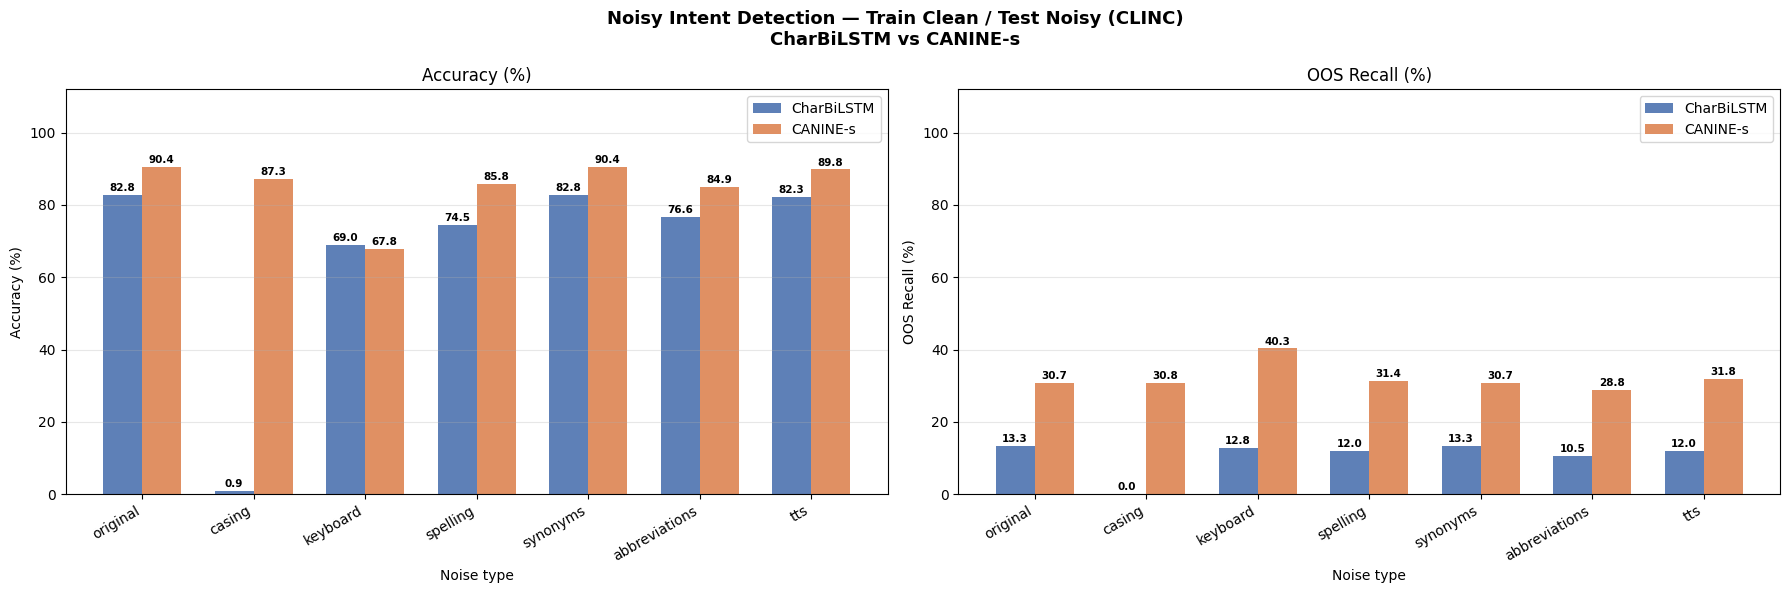

Saved to charLVL_output/noise_results.png


In [35]:
NOISE_NAMES = list(noise_variants.keys())
x = np.arange(len(NOISE_NAMES))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(
    "Noisy Intent Detection — Train Clean / Test Noisy (CLINC)\n"
    "CharBiLSTM vs CANINE-s",
    fontsize=13, fontweight="bold"
)

for ax, metric, ylabel in zip(
    axes,
    ["accuracy", "oos_recall"],
    ["Accuracy (%)", "OOS Recall (%)"],
):
    char_vals   = [char_results[n][metric]   * 100 for n in NOISE_NAMES]
    canine_vals = [canine_results[n][metric] * 100 for n in NOISE_NAMES]

    b1 = ax.bar(x - w/2, char_vals,   w, label="CharBiLSTM", color="#4C72B0", alpha=0.9)
    b2 = ax.bar(x + w/2, canine_vals, w, label="CANINE-s",   color="#DD8452", alpha=0.9)

    for b in [*b1, *b2]:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.5, f"{h:.1f}",
                ha="center", va="bottom", fontsize=7.5, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(NOISE_NAMES, rotation=30, ha="right")
    ax.set_ylim(0, 112)
    ax.set_xlabel("Noise type")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "noise_results.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {SAVE_DIR}/noise_results.png")

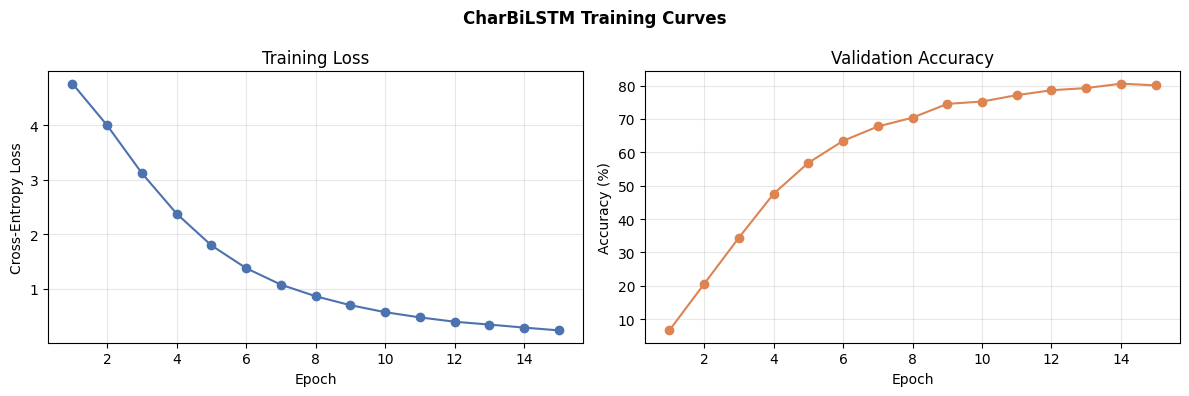

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("CharBiLSTM Training Curves", fontsize=12, fontweight="bold")
ep_x = range(1, len(char_history["loss"]) + 1)

ax1.plot(ep_x, char_history["loss"], marker="o", color="#4C72B0")
ax1.set(title="Training Loss", xlabel="Epoch", ylabel="Cross-Entropy Loss")
ax1.grid(alpha=0.3)

ax2.plot(ep_x, [v*100 for v in char_history["val_acc"]], marker="o", color="#DD8452")
ax2.set(title="Validation Accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(SAVE_DIR / "char_bilstm_training.png"), dpi=150, bbox_inches="tight")
plt.show()

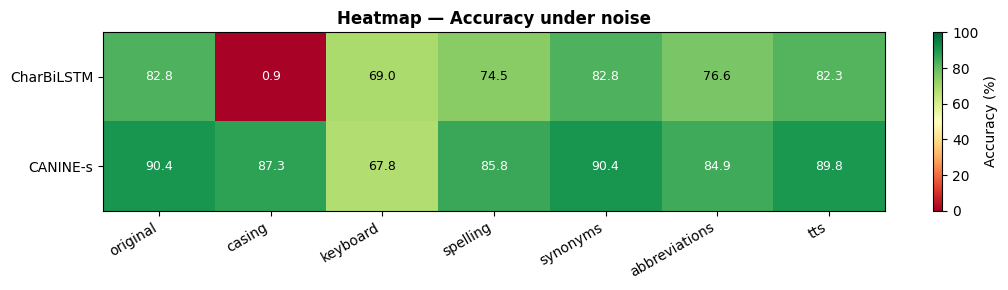

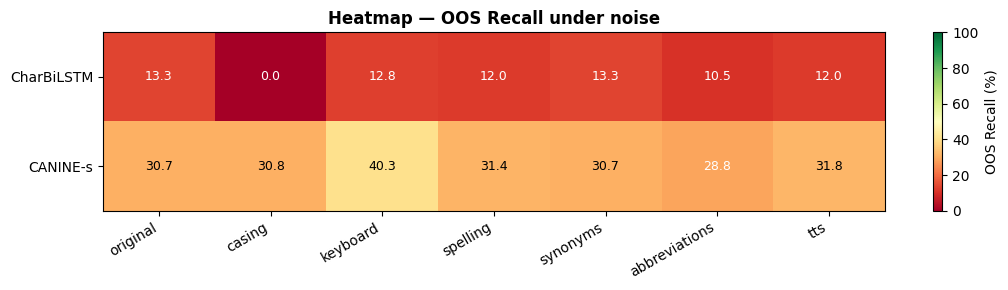

In [ ]:
import matplotlib.colors as mcolors

models = ["CharBiLSTM", "CANINE-s"]
all_res = [char_results, canine_results]

for metric, title in [("accuracy", "Accuracy"), ("oos_recall", "OOS Recall")]:
    matrix = np.array([[res[n][metric]*100 for n in NOISE_NAMES] for res in all_res])

    fig, ax = plt.subplots(figsize=(11, 3))
    im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
    plt.colorbar(im, ax=ax, label=f"{title} (%)")

    ax.set_xticks(range(len(NOISE_NAMES)))
    ax.set_xticklabels(NOISE_NAMES, rotation=30, ha="right")
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(models)
    ax.set_title(f"Heatmap — {title} under noise", fontweight="bold")

    for i in range(len(models)):
        for j in range(len(NOISE_NAMES)):
            ax.text(j, i, f"{matrix[i,j]:.1f}", ha="center", va="center",
                    fontsize=9, color="black" if 30 < matrix[i,j] < 80 else "white")

    plt.tight_layout()
    plt.savefig(f"{SAVE_DIR}/heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()